In [1]:
USE_OPTUNA = True

# Main Orchestration

This notebook runs the ASM1 simulation model from the source package and persists the generated dataset and metadata under the repository data contract.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from src.models.simulation.asm2d_tcn_simulation import get_asm2d_tcn_matrices, load_asm2d_tcn_simulation_params
from src.utils.simulation import get_repo_root

repo_root = get_repo_root()
simulation_dir = repo_root / "data" / "asm2d-tcn" / "simulation"

dataset_candidates = {
    path.stem.removeprefix("data_"): path
    for path in simulation_dir.glob("data_*.csv")
}
metadata_candidates = {
    path.stem.removeprefix("metadata_"): path
    for path in simulation_dir.glob("metadata_*.json")
}

if not dataset_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN datasets found in {simulation_dir}")
if not metadata_candidates:
    raise FileNotFoundError(f"No ASM2d-TCN metadata files found in {simulation_dir}")

shared_timestamps = sorted(set(dataset_candidates) & set(metadata_candidates))
if shared_timestamps:
    latest_timestamp = shared_timestamps[-1]
    latest_dataset_path = dataset_candidates[latest_timestamp]
    latest_metadata_path = metadata_candidates[latest_timestamp]
else:
    latest_dataset_path = max(dataset_candidates.values(), key=lambda path: path.stat().st_mtime)
    latest_metadata_path = max(metadata_candidates.values(), key=lambda path: path.stat().st_mtime)

dataset = pd.read_csv(latest_dataset_path)
metadata = json.loads(latest_metadata_path.read_text(encoding="utf-8"))
artifact_paths = {
    "dataset_csv": latest_dataset_path,
    "metadata_json": latest_metadata_path,
}

workbook_path = repo_root / "data" / "asm2d-tcn" / "asm2d_tcn_workbook.xlsx"
if not workbook_path.exists():
    raise FileNotFoundError(f"ASM2d-TCN workbook not found: {workbook_path}")

state_columns = list(metadata["state_columns"])
measured_output_columns = list(metadata["measured_output_columns"])

stoichiometric_frame = pd.read_excel(
    workbook_path,
    sheet_name="stoichiometric_matrix",
    engine="openpyxl",
)
composition_frame = pd.read_excel(
    workbook_path,
    sheet_name="composition_matrix",
    engine="openpyxl",
)

petersen_matrix = stoichiometric_frame.loc[:, state_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
composition_by_state = (
    composition_frame.loc[:, ["state_variable", *measured_output_columns]]
    .set_index("state_variable")
    .reindex(state_columns)
)
composition_matrix = (
    composition_by_state.loc[:, measured_output_columns]
    .T
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

matrix_source = str(workbook_path.relative_to(repo_root))
if np.isnan(petersen_matrix).any() or np.isnan(composition_matrix).any():
    matrix_bundle = get_asm2d_tcn_matrices(load_asm2d_tcn_simulation_params(repo_root))
    petersen_matrix = matrix_bundle["petersen_matrix"]
    composition_matrix = matrix_bundle["composition_matrix"]
    matrix_source = "runtime matrix bundle (workbook formulas unresolved)"

print(f"Loaded {len(dataset)} rows for {metadata['simulation_name']}.")
print(f"Dataset loaded from: {artifact_paths['dataset_csv']}")
print(f"Metadata loaded from: {artifact_paths['metadata_json']}")
print(f"Matrix source: {matrix_source}")
print(f"Petersen matrix shape: {petersen_matrix.shape}")
print(f"Composition matrix shape: {composition_matrix.shape}")

display(dataset.head())
display(pd.Series(metadata, name="value").to_frame())
display(pd.DataFrame(petersen_matrix, index=metadata["processes"], columns=state_columns))
display(pd.DataFrame(composition_matrix, index=measured_output_columns, columns=state_columns))

ImportError: cannot import name 'get_asm2d_tcn_matrices' from 'src.models.simulation' (c:\Users\eselerio\projects\pibre-model\src\models\simulation\__init__.py)

In [6]:
import numpy as np
from scipy.linalg import null_space

cobre_constraint_basis = null_space(petersen_matrix)
cobre_A_matrix = cobre_constraint_basis.T

cobre_A_matrix = np.round(cobre_A_matrix, 5)
cobre_A_matrix[np.abs(cobre_A_matrix) < 1e-10] = 0.0

for row_index in range(cobre_A_matrix.shape[0]):
    non_zero_entries = cobre_A_matrix[row_index, cobre_A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        cobre_A_matrix[row_index, :] = cobre_A_matrix[row_index, :] / non_zero_entries[0]

macroscopic_stoichiometric_matrix = petersen_matrix @ composition_matrix.T
measured_constraint_basis = null_space(macroscopic_stoichiometric_matrix)
A_matrix = measured_constraint_basis.T

A_matrix = np.round(A_matrix, 5)
A_matrix[np.abs(A_matrix) < 1e-10] = 0.0

for row_index in range(A_matrix.shape[0]):
    non_zero_entries = A_matrix[row_index, A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        A_matrix[row_index, :] = A_matrix[row_index, :] / non_zero_entries[0]

print(f"Fractional Petersen matrix shape: {petersen_matrix.shape}")
print(f"COBRE invariant matrix shape: {cobre_A_matrix.shape}")
print(f"Measured-space invariant matrix shape kept for downstream regressors: {A_matrix.shape}")
display(
    pd.DataFrame(
        cobre_A_matrix,
        index=[f"constraint_{index + 1}" for index in range(cobre_A_matrix.shape[0])],
        columns=metadata["state_columns"],
    )
)

Fractional Petersen matrix shape: (7, 11)
COBRE invariant matrix shape: (4, 11)
Measured-space invariant matrix shape kept for downstream regressors: (0, 4)


,S_S,S_I,S_NH4_N,S_NO3_N,S_PO4_P,S_O2,S_Alkalinity,X_I,X_S,X_H,X_AUT
constraint_1,1.0,0.645158,-1.285714,1.643908,1.807923,0.0,0.460484,3.278061,1.0,1.418117,1.418117
constraint_2,1.0,-7.844840,-0.784403,1.142608,-7.541609,0.0,0.320084,3.064970,1.0,1.274291,1.274291
constraint_3,1.0,9.048944,3.817788,-3.459516,-7.953014,0.0,-0.969095,3.925745,1.0,1.661865,1.661865
constraint_4,1.0,-7.797403,13.519244,-13.161275,8.336009,0.0,-3.686659,6.306257,1.0,2.821960,2.821960


In [7]:
import pandas as pd

from src.utils.process import (
    build_cobre_supervised_dataset,
    build_measured_supervised_dataset,
    make_train_test_split,
    sample_dataset_fraction,
)
from src.utils.simulation import load_ml_orchestration_params

ml_orchestration_params = load_ml_orchestration_params()
ml_orchestration = ml_orchestration_params["hyperparameters"]

measured_dataset = build_measured_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
)
cobre_dataset = build_cobre_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
)
main_dataset_splits = make_train_test_split(
    measured_dataset,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
cobre_dataset_splits = make_train_test_split(
    cobre_dataset,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
optuna_dataset = sample_dataset_fraction(
    main_dataset_splits.train,
    fraction=float(ml_orchestration["optuna_dataset_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
tuning_dataset_splits = make_train_test_split(
    optuna_dataset,
    test_fraction=float(ml_orchestration["optuna_test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)

split_sizes = {
    "train": len(main_dataset_splits.train.features),
    "test": len(main_dataset_splits.test.features),
    "optuna_dataset": len(optuna_dataset.features),
    "optuna_train": len(tuning_dataset_splits.train.features),
    "optuna_test": len(tuning_dataset_splits.test.features),
}
cobre_split_sizes = {
    "train": len(cobre_dataset_splits.train.features),
    "test": len(cobre_dataset_splits.test.features),
    "fractional_features": len(cobre_dataset.features.columns),
    "measured_targets": len(cobre_dataset.targets.columns),
    "fractional_constraints": len(cobre_dataset.constraint_reference.columns),
}
split_alignment_ok = (
    main_dataset_splits.train.features.index.equals(cobre_dataset_splits.train.features.index)
    and main_dataset_splits.test.features.index.equals(cobre_dataset_splits.test.features.index)
)

print("Notebook-managed ML orchestration is ready.")
print(f"Measured-space split sizes: train={split_sizes['train']}, test={split_sizes['test']}")
print(
    "COBRE split sizes: "
    f"train={cobre_split_sizes['train']}, test={cobre_split_sizes['test']}, "
    f"fractional_features={cobre_split_sizes['fractional_features']}, "
    f"measured_targets={cobre_split_sizes['measured_targets']}, "
    f"fractional_constraints={cobre_split_sizes['fractional_constraints']}"
)
print(f"Measured and COBRE splits aligned: {split_alignment_ok}")
print(
    "Optuna subset sizes: "
    f"dataset={split_sizes['optuna_dataset']}, train={split_sizes['optuna_train']}, test={split_sizes['optuna_test']}"
)

display(pd.DataFrame([ml_orchestration]))
display(pd.DataFrame([split_sizes]))
display(pd.DataFrame([cobre_split_sizes]))

Notebook-managed ML orchestration is ready.
Measured-space split sizes: train=8000, test=2000
COBRE split sizes: train=8000, test=2000, fractional_features=13, measured_targets=4, fractional_constraints=11
Measured and COBRE splits aligned: True
Optuna subset sizes: dataset=4000, train=3200, test=800


,random_seed,test_fraction,optuna_dataset_fraction,optuna_test_fraction,tuning_epochs,n_trials,timeout_seconds
0,42,0.2,0.5,0.2,500,30,None


,train,test,optuna_dataset,optuna_train,optuna_test
0,8000,2000,4000,3200,800


,train,test,fractional_features,measured_targets,fractional_constraints
0,8000,2000,13,4,11


## COBRE

This section now follows the strict fractional-space COBRE formulation. The notebook passes operational variables and influent ASM1 fractions into the bilinear model, derives the invariant matrix from the Petersen null space, and collapses the projected fractional prediction into the measured composite space with the composition matrix.

COBRE still uses a closed-form projected OLS solve with `ols_backend="numpy_lstsq"`, so there is no Optuna tuning branch for this model.

In [8]:
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline

cobre_params = load_cobre_params()
cobre_hyperparameters = dict(cobre_params["training_defaults"])

cobre_result = run_cobre_pipeline(
    cobre_dataset_splits.train,
    cobre_dataset_splits.test,
    cobre_A_matrix,
    composition_matrix=composition_matrix,
    model_params=cobre_params,
    model_hyperparameters=cobre_hyperparameters,
    persist_artifacts=True,
)

print("COBRE training complete.")
print(f"Operational inputs: {', '.join(metadata['operational_columns'])}")
print(f"Fractional influent states: {', '.join(metadata['state_columns'])}")
print(f"Measured-output targets: {', '.join(metadata['measured_output_columns'])}")
print(f"COBRE split sizes: {cobre_split_sizes}")
print(f"Saved model bundle: {cobre_result['artifact_paths']['model_bundle']}")
print(f"Saved metrics summary: {cobre_result['artifact_paths']['metrics']}")

display(pd.DataFrame([cobre_result["best_hyperparameters"]]))
display(pd.DataFrame([cobre_split_sizes]))
display(pd.Series(cobre_result["artifact_paths"], name="path").to_frame())
display(
    pd.DataFrame(
        cobre_result["model_bundle"]["collapse_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
    )
)
display(
    pd.DataFrame(
        cobre_result["model_bundle"]["pass_through_operator"],
        index=metadata["measured_output_columns"],
        columns=metadata["state_columns"],
    )
)
display(cobre_result["train_report"]["aggregate_metrics"])
display(cobre_result["test_report"]["aggregate_metrics"])
display(cobre_result["test_report"]["per_target_metrics"])
display(cobre_result["test_report"]["constraint_residuals"].describe().T)

COBRE training complete.
Operational inputs: HRT, Aeration
Fractional influent states: S_S, S_I, S_NH4_N, S_NO3_N, S_PO4_P, S_O2, S_Alkalinity, X_I, X_S, X_H, X_AUT
Measured-output targets: COD, TSS, TN, TP
COBRE split sizes: {'train': 8000, 'test': 2000, 'fractional_features': 13, 'measured_targets': 4, 'fractional_constraints': 11}
Saved model bundle: C:\Users\eselerio\projects\pibre-model\results\cobre\model_20260329_232402.pkl
Saved metrics summary: C:\Users\eselerio\projects\pibre-model\results\cobre\metrics_20260329_232402.json


,objective,solver,ols_backend,include_bias_term,lstsq_rcond
0,projected_ols,multivariate_lstsq,numpy_lstsq,True,None


,train,test,fractional_features,measured_targets,fractional_constraints
0,8000,2000,13,4,11


,path
model_bundle,C:\Users\eselerio\projects\pibre-model\results...
metrics,C:\Users\eselerio\projects\pibre-model\results...
optuna,None


,S_S,S_I,S_NH4_N,S_NO3_N,S_PO4_P,S_O2,S_Alkalinity,X_I,X_S,X_H,X_AUT
COD,0.547008,-6.137851e-07,-0.057643,-0.104620,0.006347,0.0,-0.029303,-0.579321,0.547008,0.319059,0.319059
TSS,-0.322937,-1.817246e-07,-0.059477,-0.056195,-0.003987,0.0,-0.015741,-0.379669,0.427063,0.412807,0.412807
TN,-0.040870,-6.244134e-06,1.000508,0.984853,0.002675,0.0,-0.004243,-0.111335,-0.000870,0.025098,0.025098
TP,0.004798,-2.393480e-08,0.001309,0.000417,0.000075,0.0,0.000116,-0.011115,0.011798,0.007280,0.007280


,S_S,S_I,S_NH4_N,S_NO3_N,S_PO4_P,S_O2,S_Alkalinity,X_I,X_S,X_H,X_AUT
COD,0.452992,1.000001e+00,0.057643,0.104620,-0.006347,0.0,0.029303,1.579321,0.452992,0.680941,0.680941
TSS,0.322937,1.817246e-07,0.059477,0.056195,0.003987,0.0,0.015741,1.129669,0.322937,0.487193,0.487193
TN,0.040870,6.244134e-06,-0.000508,0.015147,-0.002675,0.0,0.004243,0.141335,0.040870,0.060902,0.060902
TP,-0.004798,2.393480e-08,-0.001309,-0.000417,0.999925,0.0,-0.000116,0.016115,-0.004798,0.012720,0.012720


,prediction_type,R2,MSE,RMSE,MAE,MAPE,constraint_mean_l2,constraint_max_l2,constraint_mean_abs,constraint_max_abs
0,raw,-18.674518,41842.445215,204.554260,146.009721,0.910508,1.383921e+03,2.221922e+03,5.884083e+02,1.804311e+03
1,projected,0.994937,2.679699,1.636979,0.737160,0.016060,6.340219e-13,2.477747e-12,2.740091e-13,2.273737e-12


,prediction_type,R2,MSE,RMSE,MAE,MAPE,constraint_mean_l2,constraint_max_l2,constraint_mean_abs,constraint_max_abs
0,raw,-18.261123,41442.651586,203.574683,145.265646,0.911436,1.370067e+03,2.161865e+03,5.809175e+02,1.781570e+03
1,projected,0.995538,1.368913,1.170006,0.740955,0.015621,6.218887e-13,2.721369e-12,2.690444e-13,1.961098e-12


,target,raw_R2,raw_MSE,raw_RMSE,raw_MAE,raw_MAPE,projected_R2,projected_MSE,projected_RMSE,projected_MAE,projected_MAPE
0,Out_COD,-38.242672,121217.273640,348.162711,342.890836,1.025348,0.999080,2.840653,1.685424,1.210160,0.003784
1,Out_TSS,-21.997674,43797.189040,209.277780,205.264447,0.891087,0.998959,1.983186,1.408256,1.032787,0.004804
2,Out_TN,-5.514164,698.582406,26.430710,25.916973,0.796976,0.994601,0.578982,0.760909,0.507327,0.016773
3,Out_TP,-7.289983,57.561259,7.586914,6.990330,0.932333,0.989511,0.072832,0.269875,0.213546,0.037121


,count,mean,std,min,25%,50%,75%,max
raw_constraint_l2,2000.0,1.370067e+03,2.664654e+02,5.820713e+02,1.188228e+03,1.372448e+03,1.547984e+03,2.161865e+03
projected_constraint_l2,2000.0,6.218887e-13,2.591407e-13,3.552714e-14,4.375467e-13,5.926314e-13,7.626345e-13,2.721369e-12


## Additional Measured-Space Regressors

The notebook now owns the main train-test split and the optional Optuna subset used for hyperparameter optimization. Run the next cell to register the available measured-space regressors, then call `run_classical_regressor(...)` with `use_optuna=True` to tune on the notebook-managed subset or `use_optuna=False` to train with each model's `training_defaults`.

In [ ]:
import pandas as pd

from src.models.ml import (
    load_adaboost_regressor_params,
    load_catboost_regressor_params,
    load_lightgbm_regressor_params,
    load_random_forest_regressor_params,
    load_svr_regressor_params,
    load_xgboost_regressor_params,
    run_adaboost_regressor_pipeline,
    run_catboost_regressor_pipeline,
    run_lightgbm_regressor_pipeline,
    run_random_forest_regressor_pipeline,
    run_svr_regressor_pipeline,
    run_xgboost_regressor_pipeline,
)
from src.models.ml.adaboost_regressor import build_adaboost_regressor_model
from src.models.ml.catboost_regressor import build_catboost_regressor_model
from src.models.ml.lightgbm_regressor import build_lightgbm_regressor_model
from src.models.ml.random_forest_regressor import build_random_forest_regressor_model
from src.models.ml.svr_regressor import build_svr_regressor_model
from src.models.ml.xgboost_regressor import build_xgboost_regressor_model
from src.utils.train import tune_tabular_regressor_hyperparameters

classical_regressor_specs = {
    "xgboost_regressor": {
        "load_params": load_xgboost_regressor_params,
        "build_model": build_xgboost_regressor_model,
        "runner": run_xgboost_regressor_pipeline,
    },
    "lightgbm_regressor": {
        "load_params": load_lightgbm_regressor_params,
        "build_model": build_lightgbm_regressor_model,
        "runner": run_lightgbm_regressor_pipeline,
    },
    "catboost_regressor": {
        "load_params": load_catboost_regressor_params,
        "build_model": build_catboost_regressor_model,
        "runner": run_catboost_regressor_pipeline,
    },
    "adaboost_regressor": {
        "load_params": load_adaboost_regressor_params,
        "build_model": build_adaboost_regressor_model,
        "runner": run_adaboost_regressor_pipeline,
    },
    "random_forest_regressor": {
        "load_params": load_random_forest_regressor_params,
        "build_model": build_random_forest_regressor_model,
        "runner": run_random_forest_regressor_pipeline,
    },
    "svr_regressor": {
        "load_params": load_svr_regressor_params,
        "build_model": build_svr_regressor_model,
        "runner": run_svr_regressor_pipeline,
    },
}

def run_classical_regressor(
    model_name: str,
    *,
    use_optuna: bool = True,
    persist_artifacts: bool = True,
):
    spec = classical_regressor_specs[model_name]
    model_params = spec["load_params"]()
    selected_hyperparameters = dict(model_params["training_defaults"])
    optuna_summary = None

    if use_optuna:
        selected_hyperparameters, optuna_summary = tune_tabular_regressor_hyperparameters(
            model_name,
            spec["build_model"],
            tuning_dataset_splits.train,
            tuning_dataset_splits.test,
            A_matrix=A_matrix,
            model_params=model_params,
            n_trials=int(ml_orchestration["n_trials"]),
            timeout=ml_orchestration["timeout_seconds"],
        )

    result = spec["runner"](
        main_dataset_splits.train,
        main_dataset_splits.test,
        A_matrix,
        model_params=model_params,
        model_hyperparameters=selected_hyperparameters,
        optuna_summary=optuna_summary,
        persist_artifacts=persist_artifacts,
    )

    print(f"{model_name} training complete.")
    print(f"Saved model bundle: {result['artifact_paths']['model_bundle']}")
    print(f"Saved metrics summary: {result['artifact_paths']['metrics']}")
    print(f"Saved Optuna summary: {result['artifact_paths']['optuna']}")
    display(pd.DataFrame([result["best_hyperparameters"]]))
    display(result["train_report"]["aggregate_metrics"])
    display(result["test_report"]["aggregate_metrics"])
    display(result["test_report"]["per_target_metrics"])
    display(result["test_report"]["constraint_residuals"].describe().T)

    return result

classical_regressor_results = {}

for model_name in classical_regressor_specs:
    print(f"\n=== Running {model_name} ===")
    classical_regressor_results[model_name] = run_classical_regressor(
        model_name,
        use_optuna=USE_OPTUNA,
        persist_artifacts=True,
    )

list(classical_regressor_results)

## Analysis

Each code cell below runs the configurable dataset-size sweep for one model, returns the raw and projected train-test predictions for every sampled split, and renders the requested train-vs-test projected-metric boxplots for all measured targets. Override the default sweep settings by defining `analysis_overrides = {...}` in the notebook before running a model cell, and change `analysis_metric` if you want a projected metric other than `projected_R2`.

c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Analyze cobre: 100%|██████████| 930/930 [45:25<00:00,  2.93s/run, repeat=30, size=1e+4]


COBRE analysis complete.
Metric: projected_R2
Prediction tables returned: 1860


,min_total_samples,max_total_samples,total_sample_step,n_repeats,test_fraction,random_seed
0,100,10000,330,30,0.2,42


,model_name,dataset_size_total,repeat_index,train_size,test_size,run_seed,artifact_model_bundle_path,artifact_metrics_path,artifact_optuna_path
0,cobre,100,0,80,20,42,None,None,None
1,cobre,100,1,80,20,43,None,None,None
2,cobre,100,2,80,20,44,None,None,None
3,cobre,100,3,80,20,45,None,None,None
4,cobre,100,4,80,20,46,None,None,None


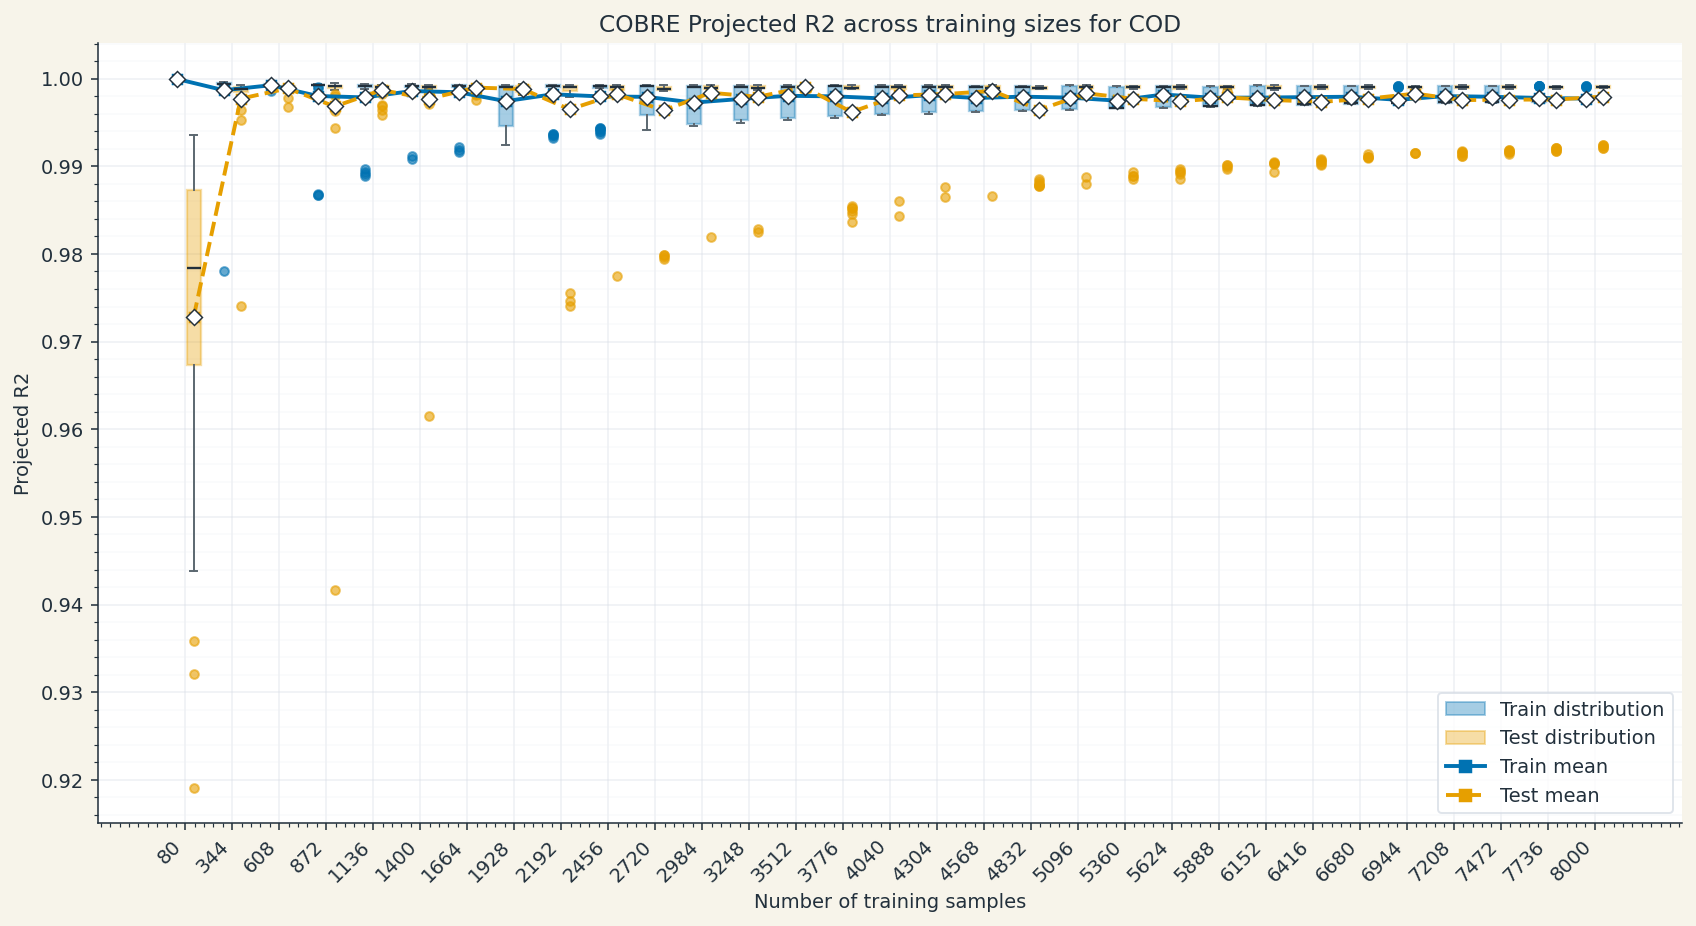

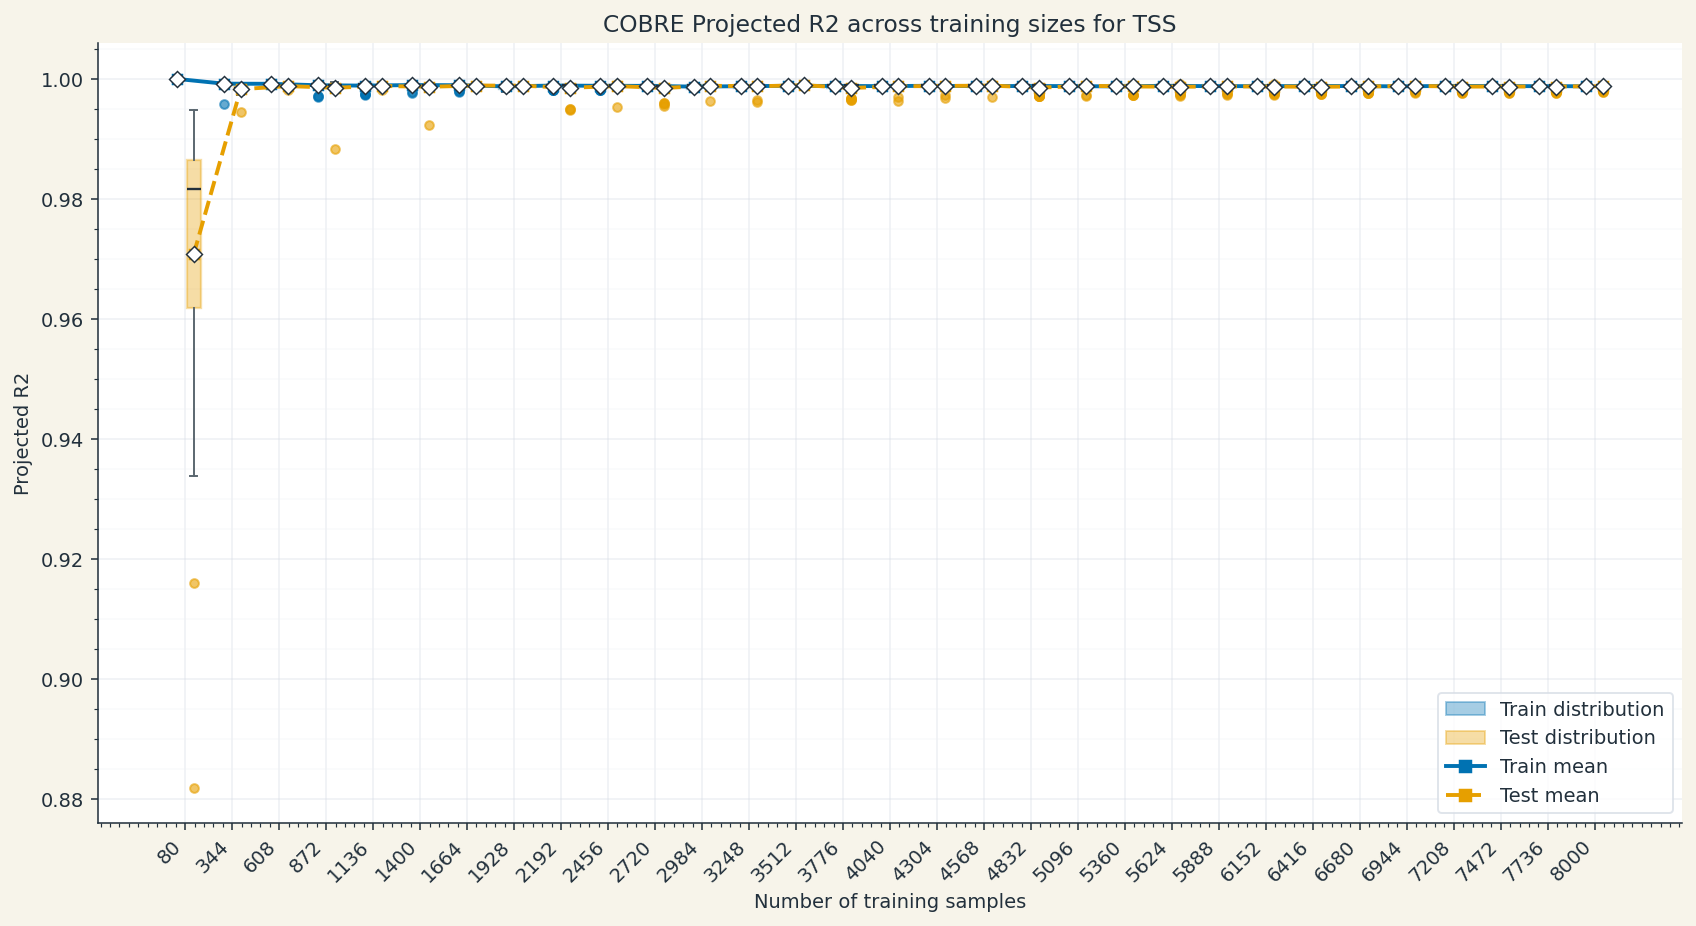

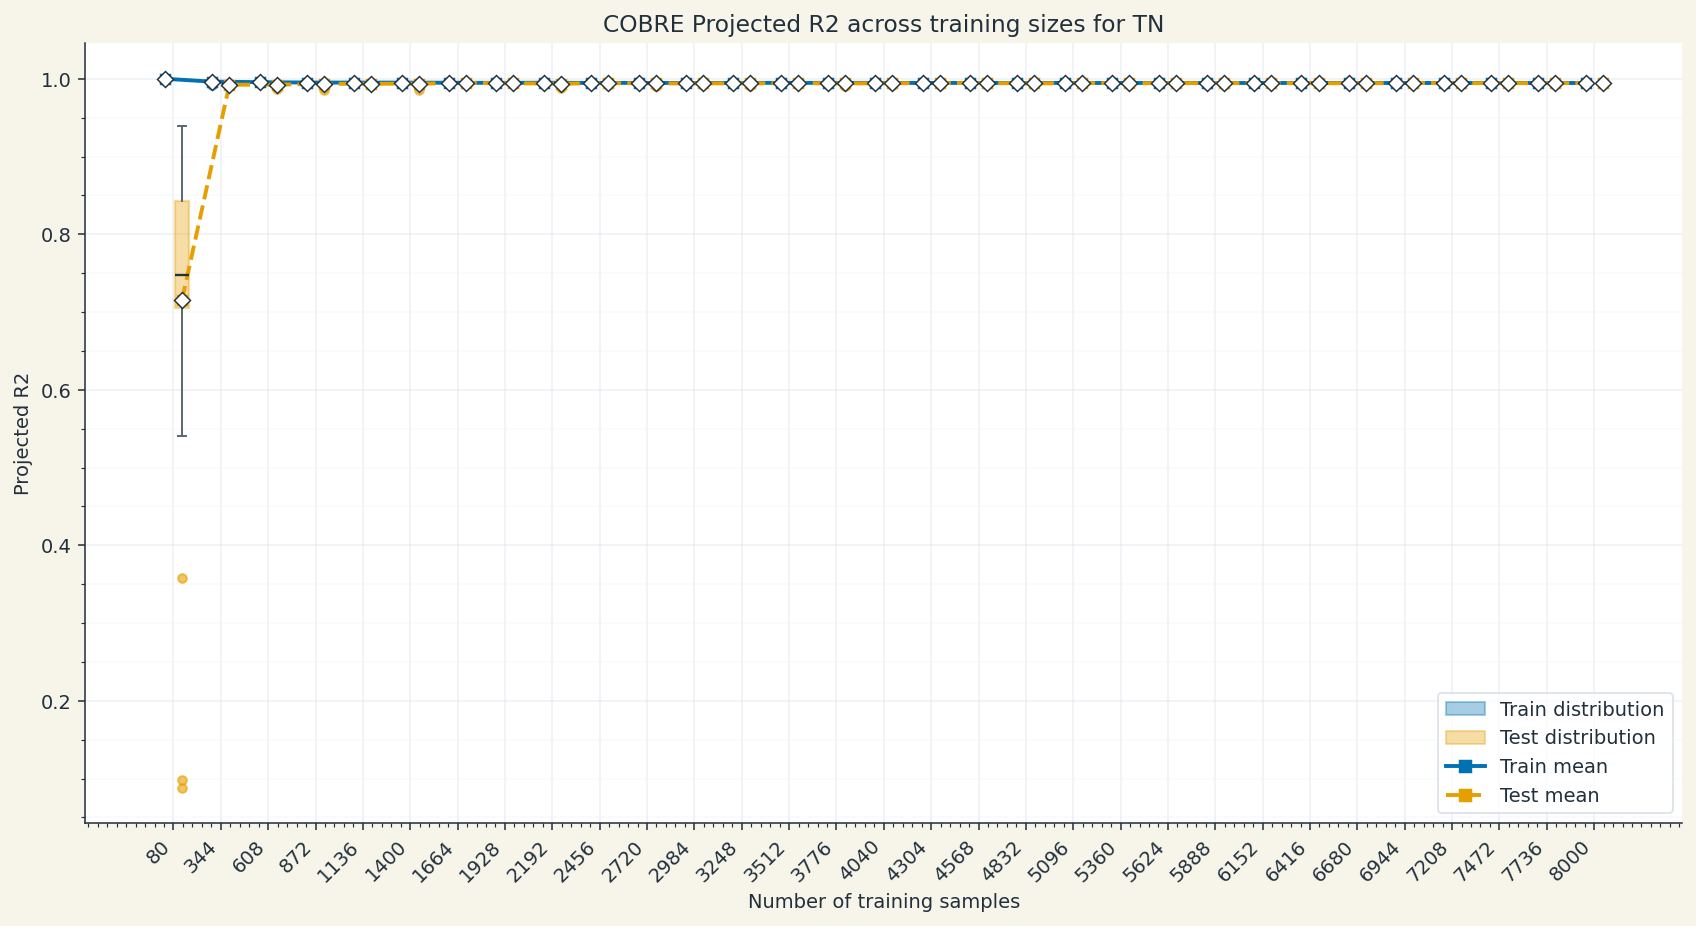

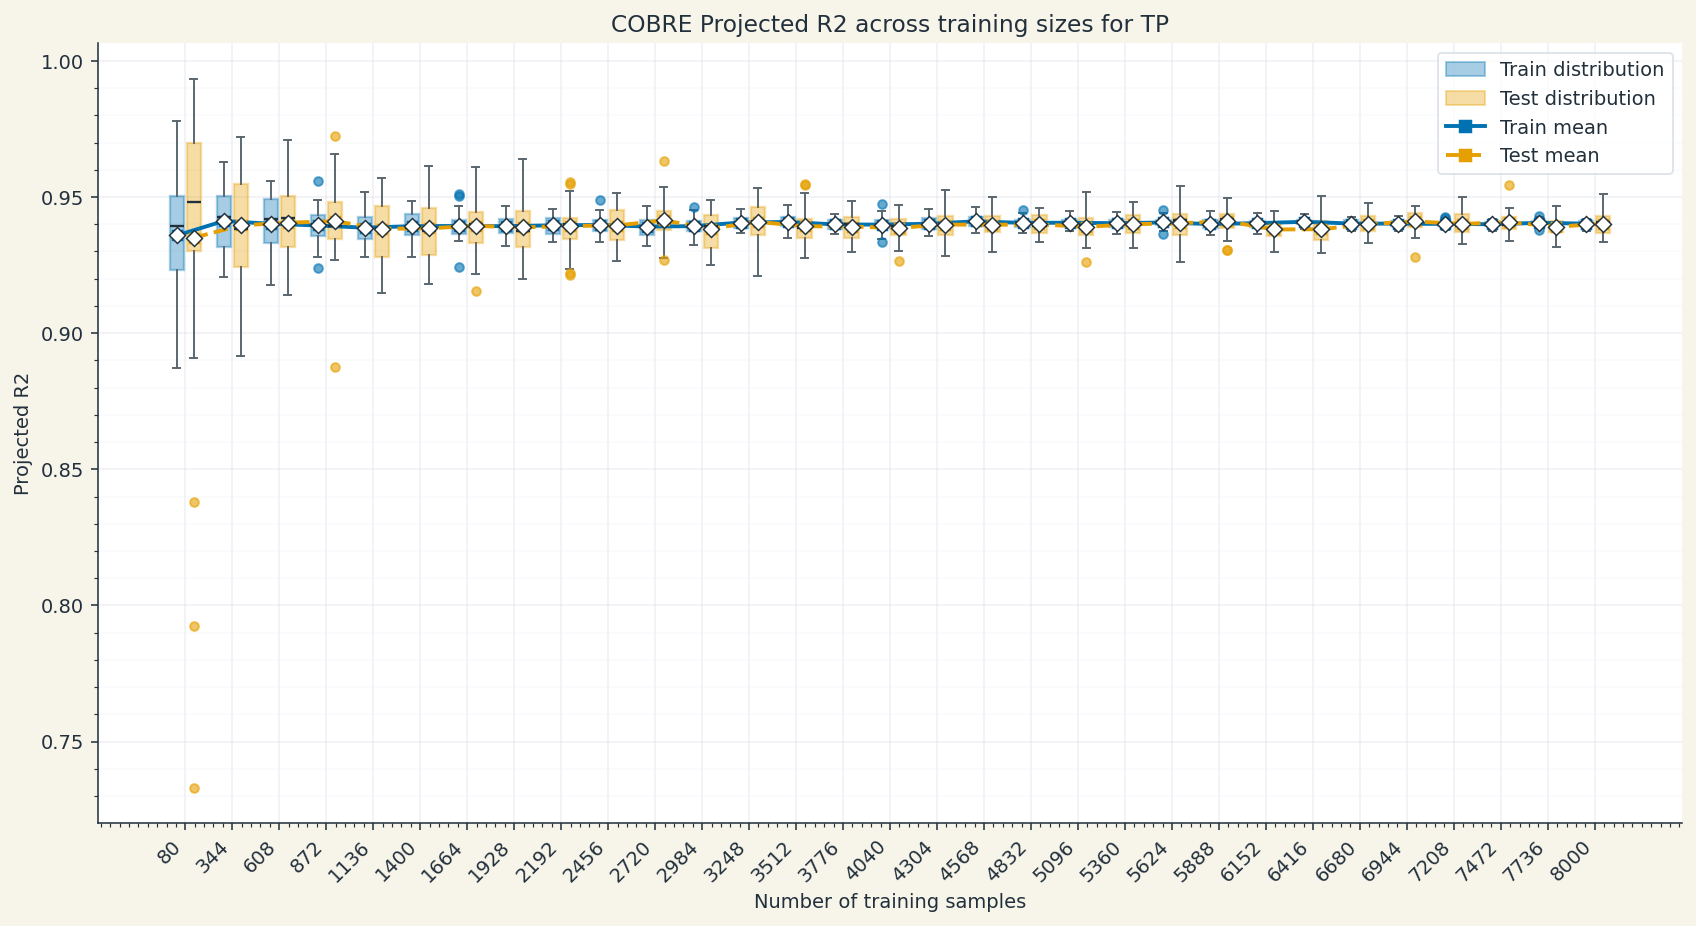

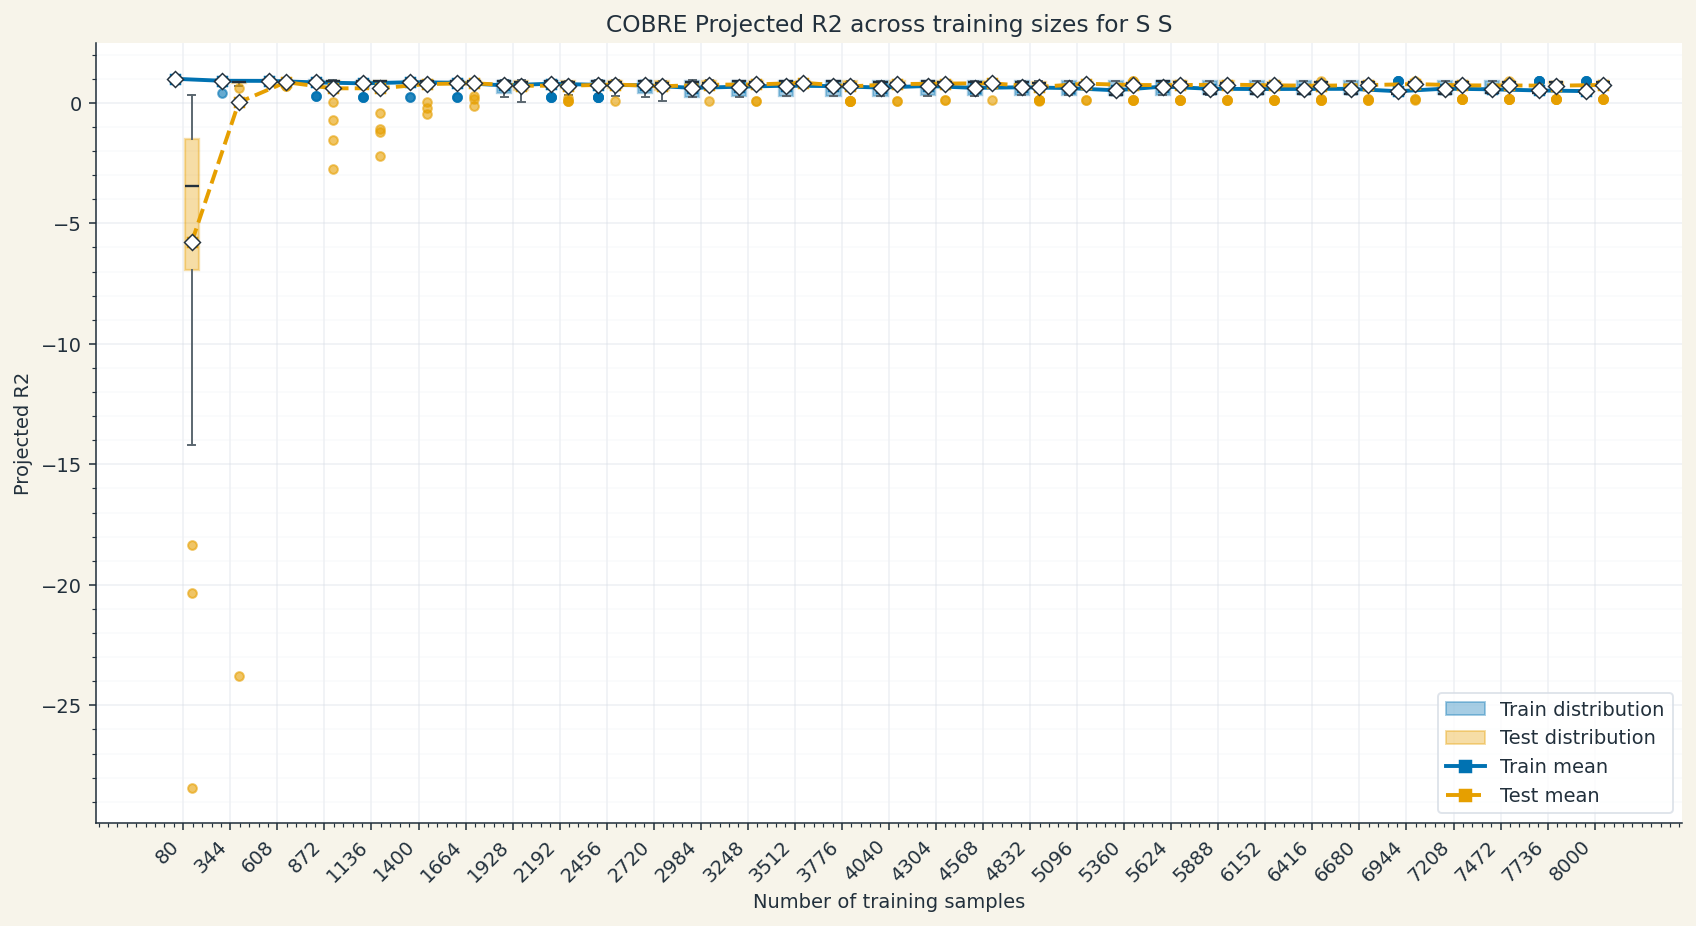

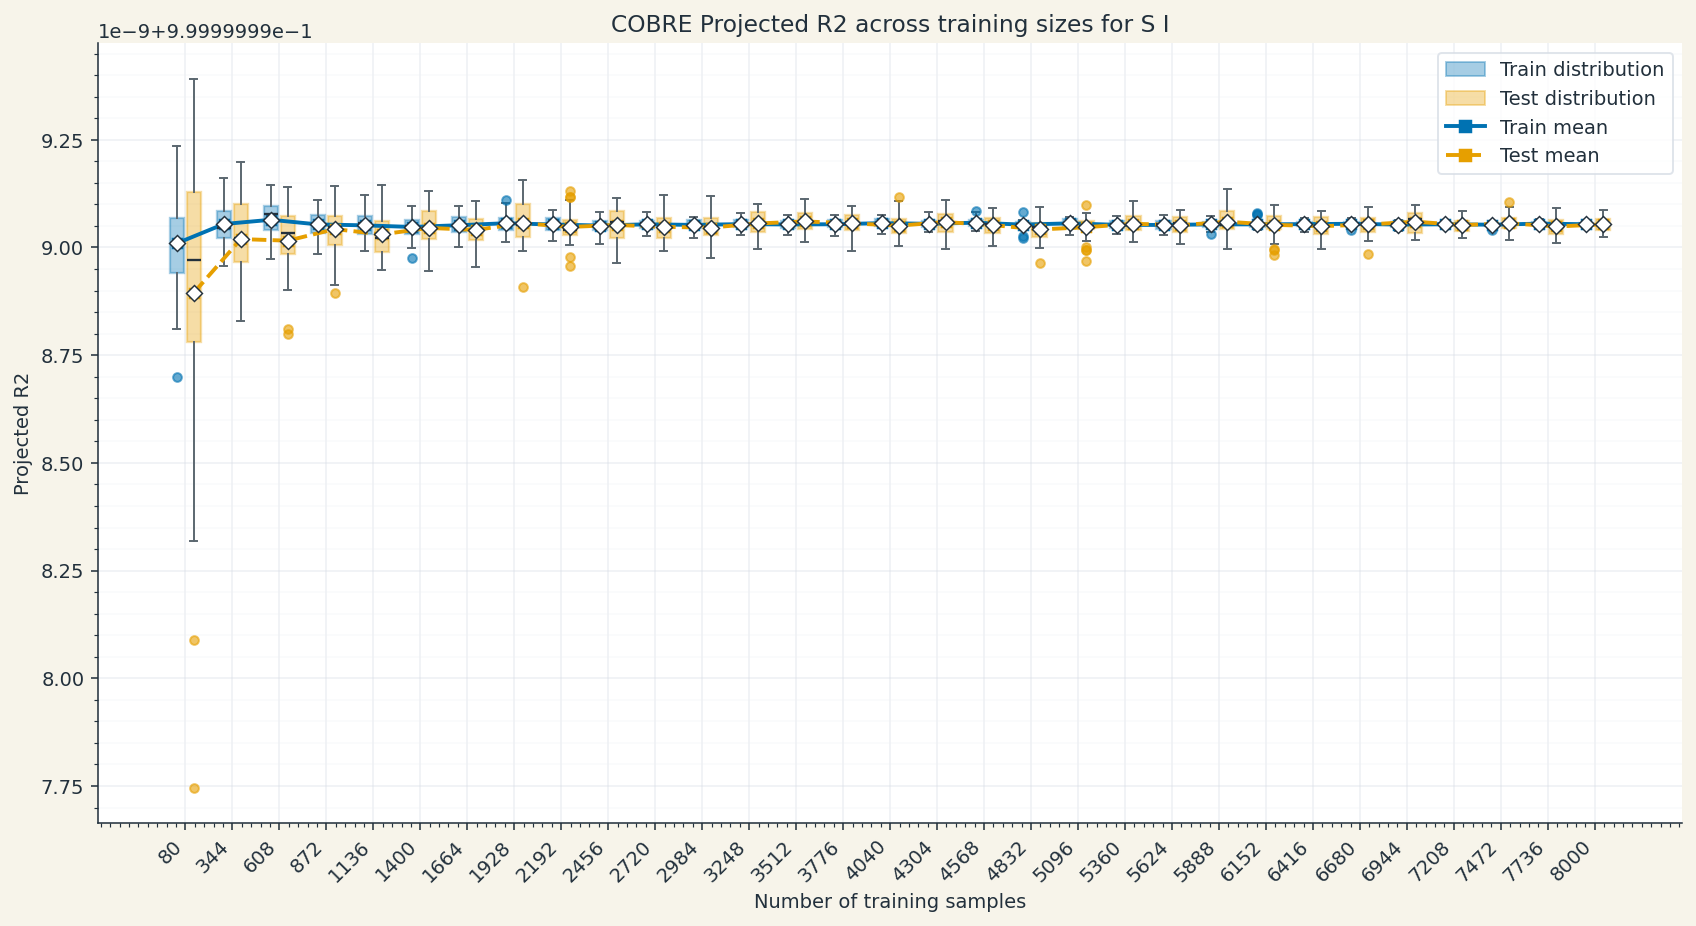

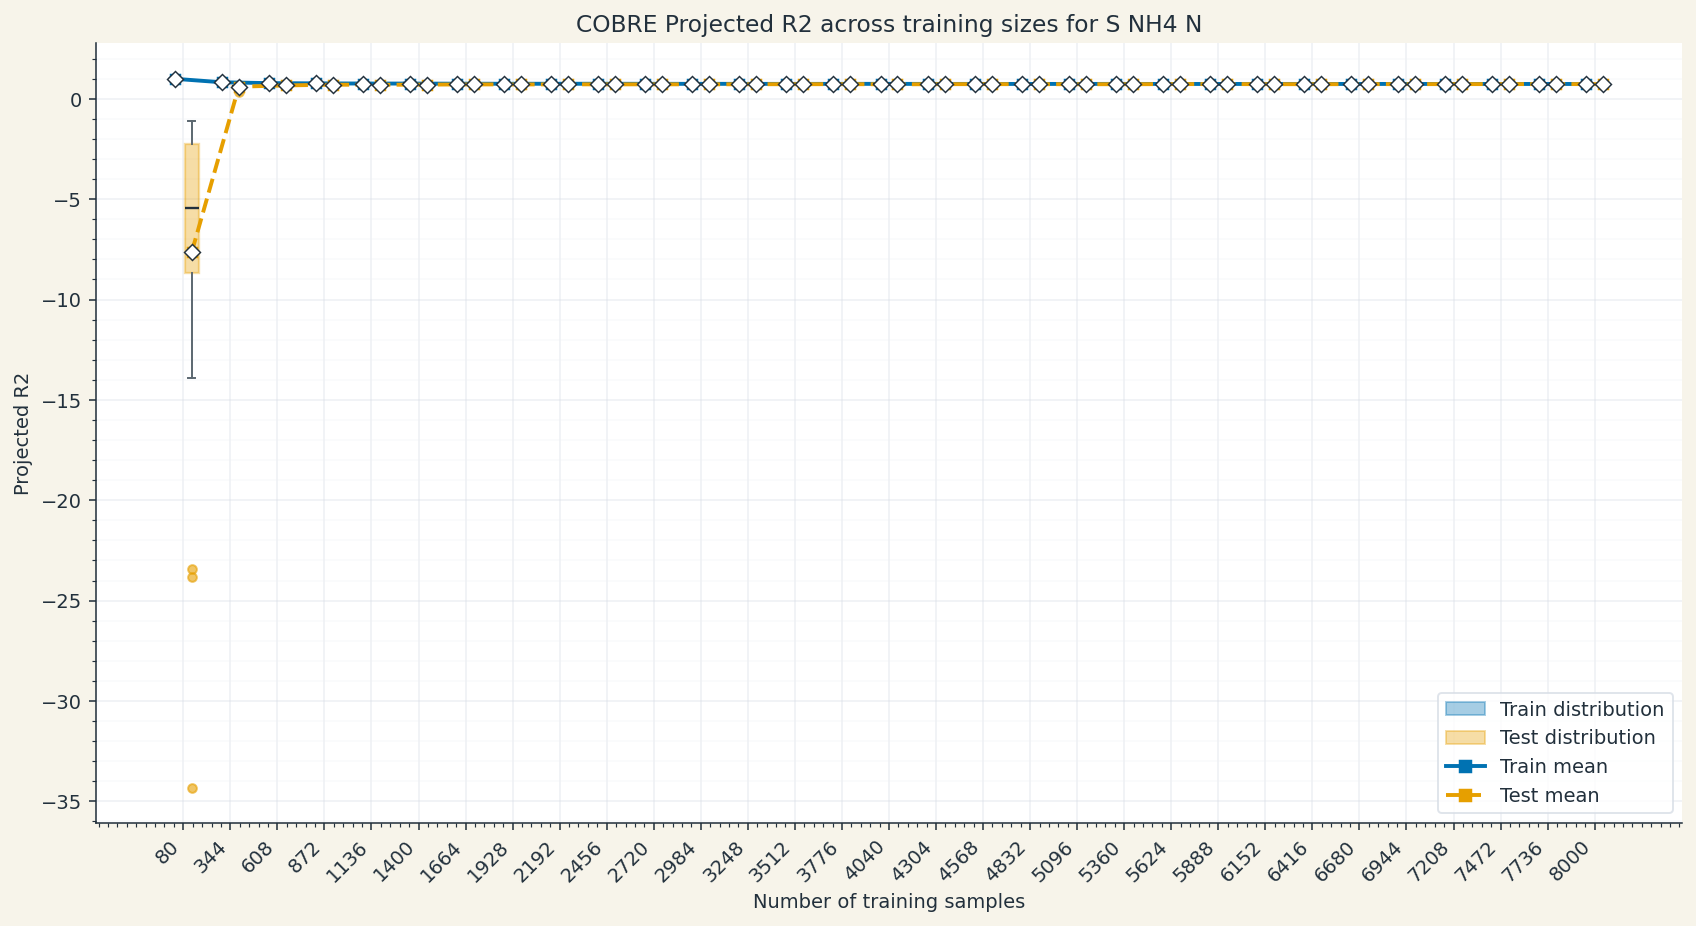

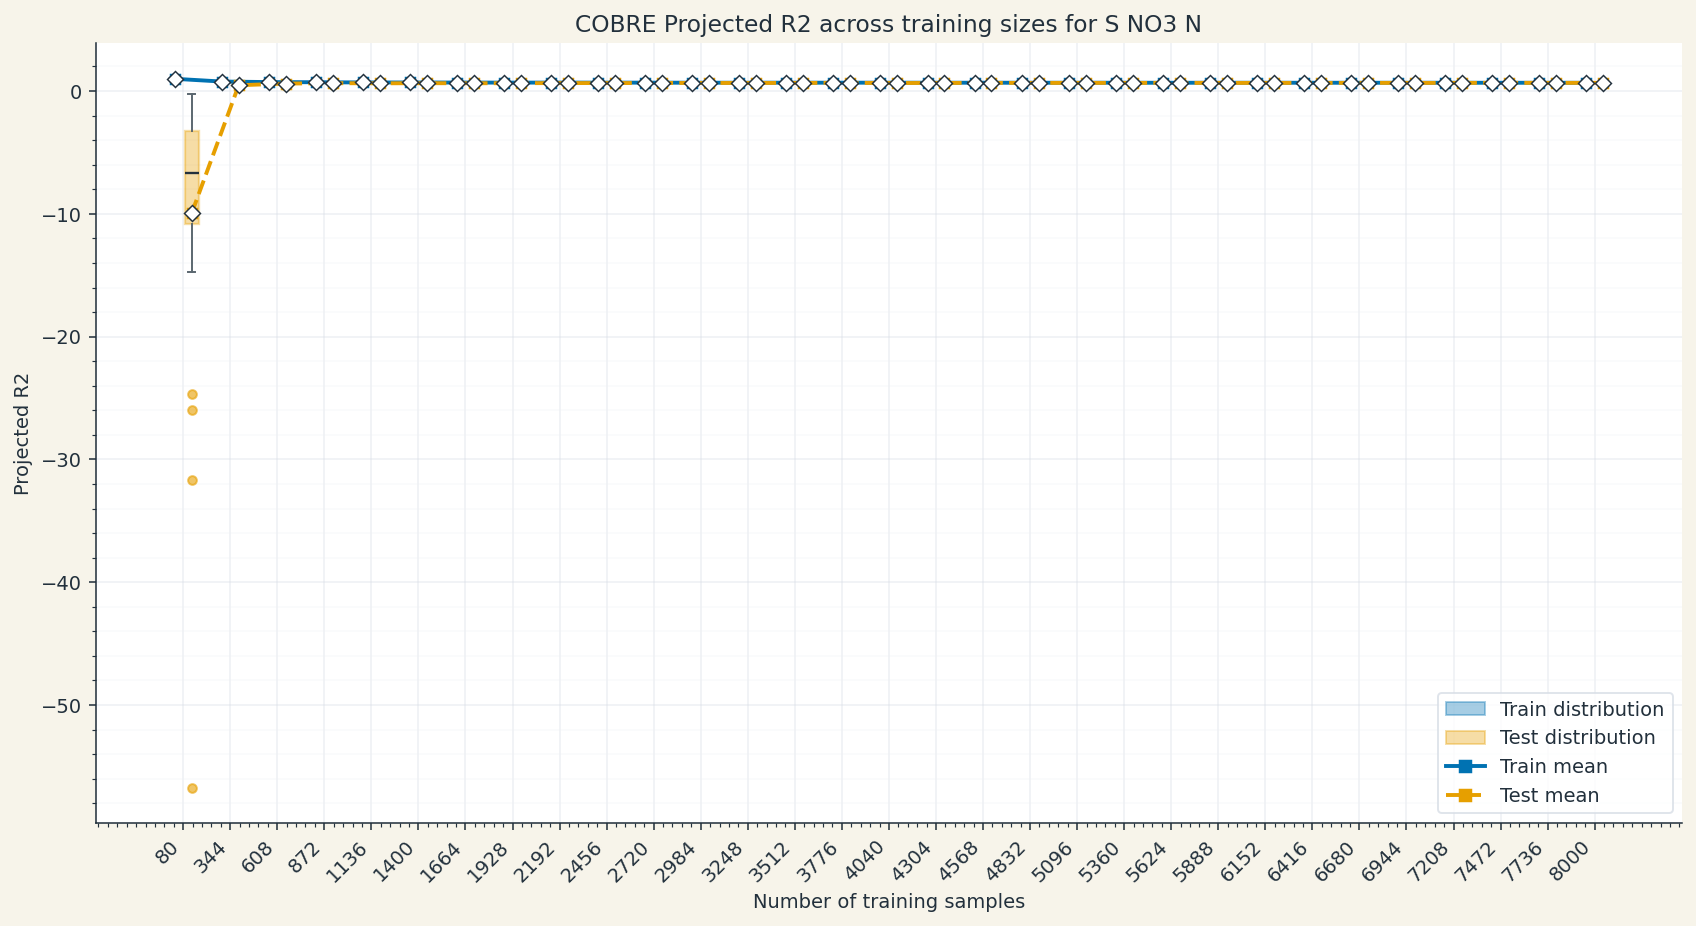

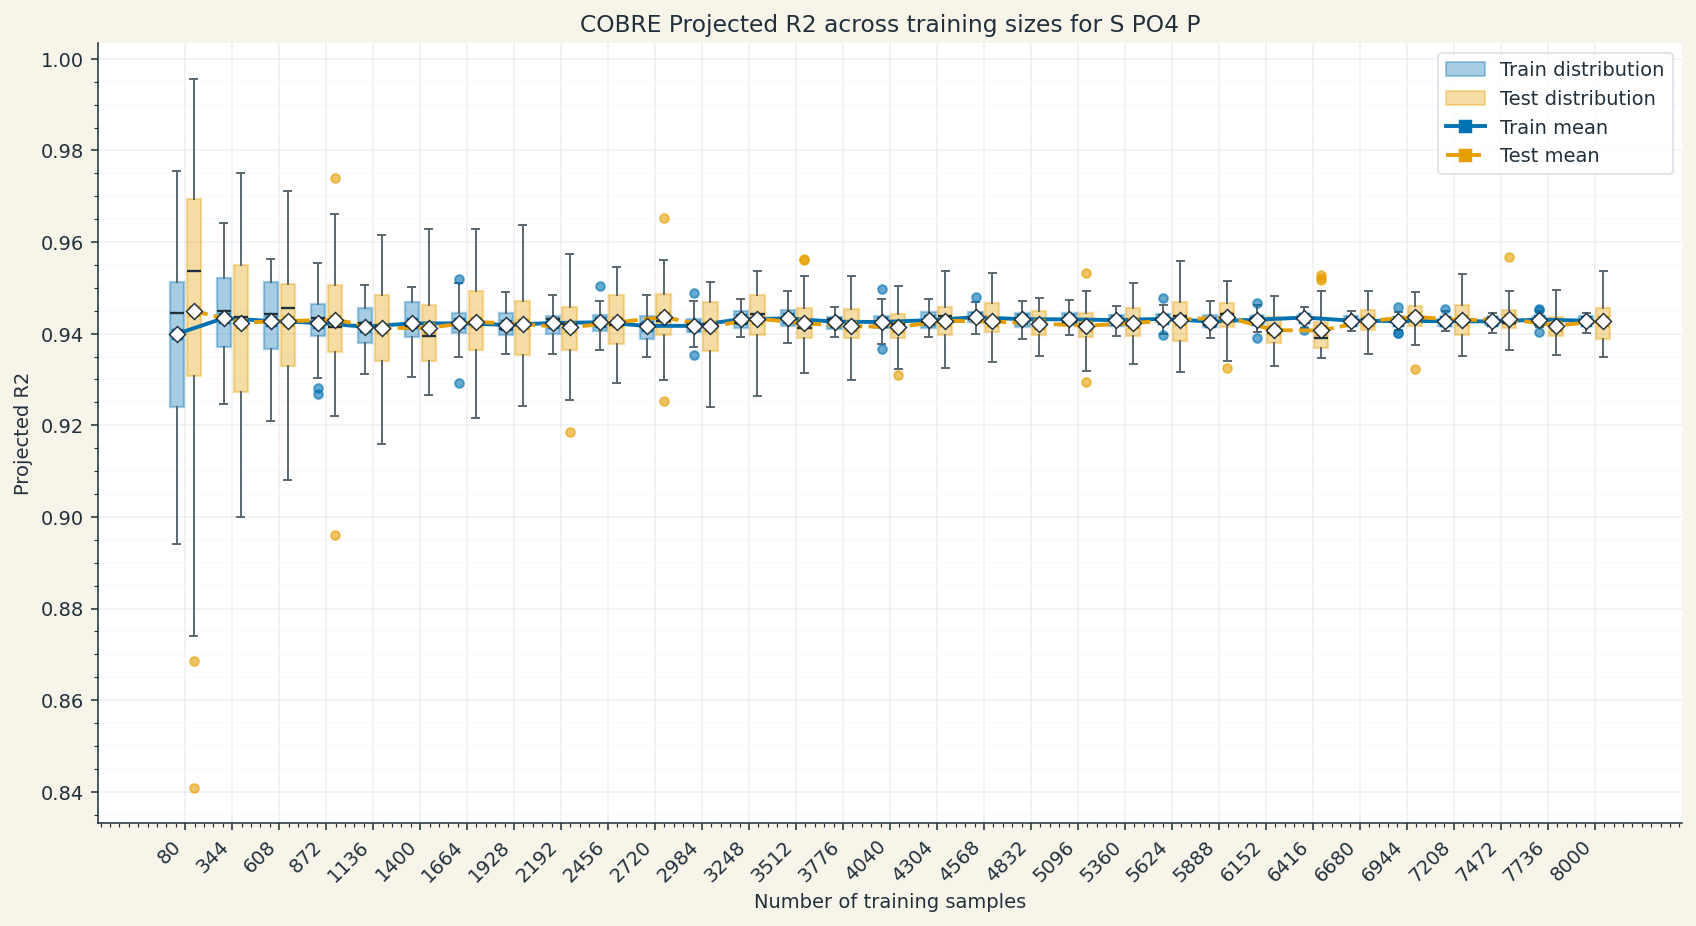

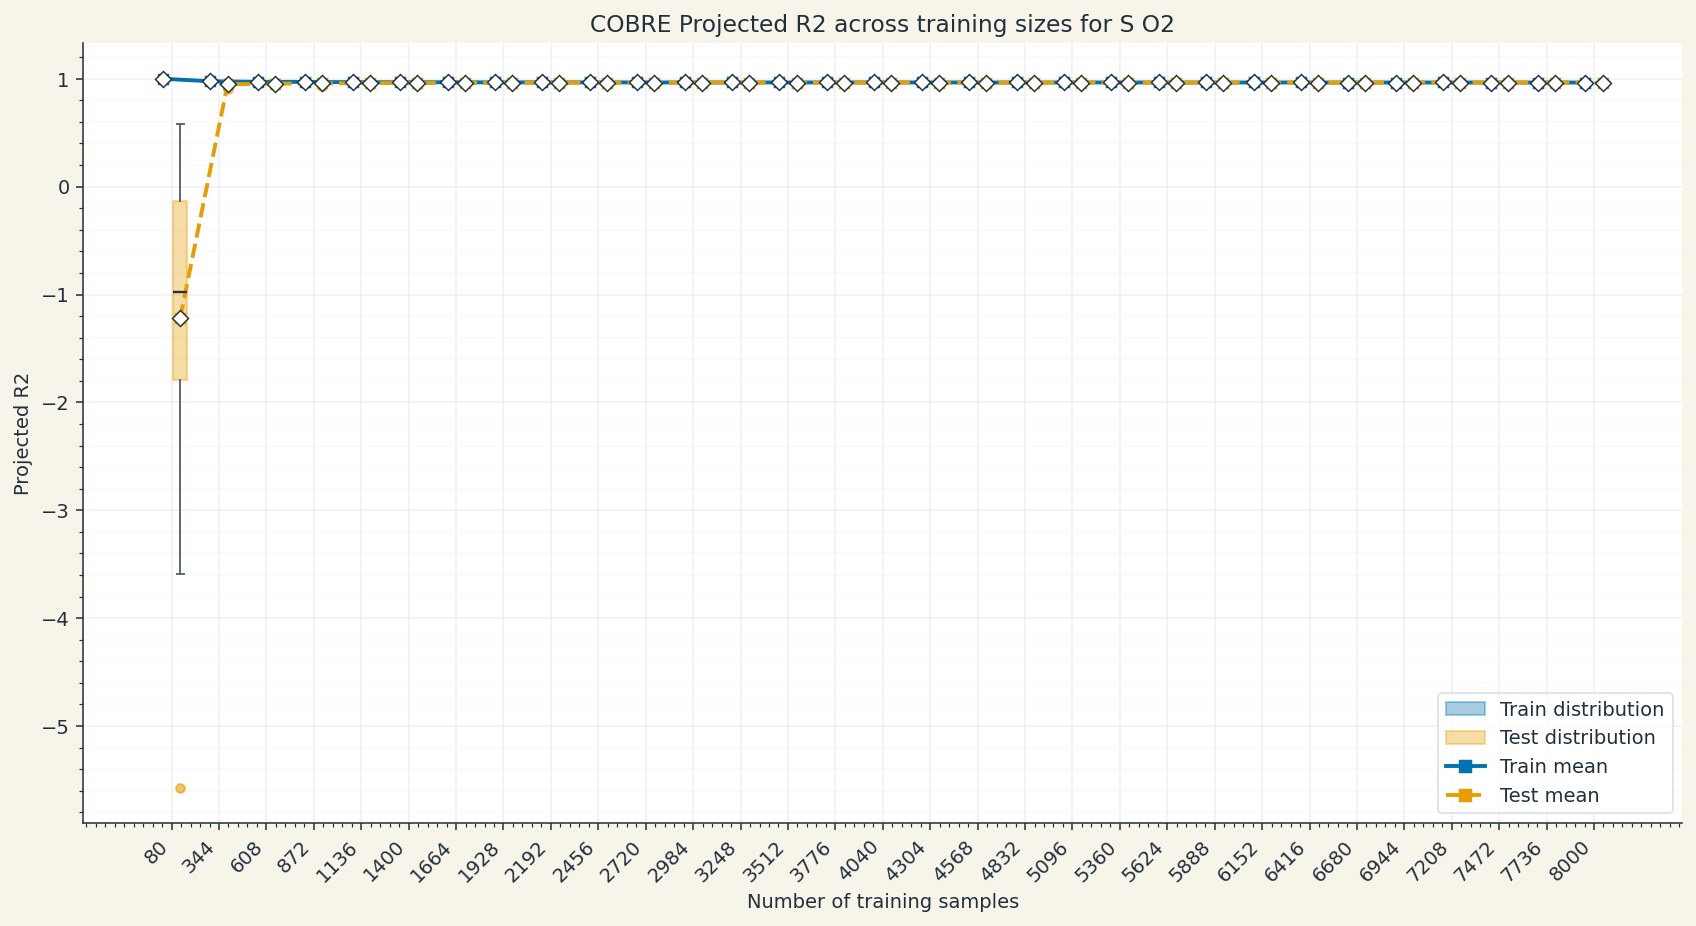

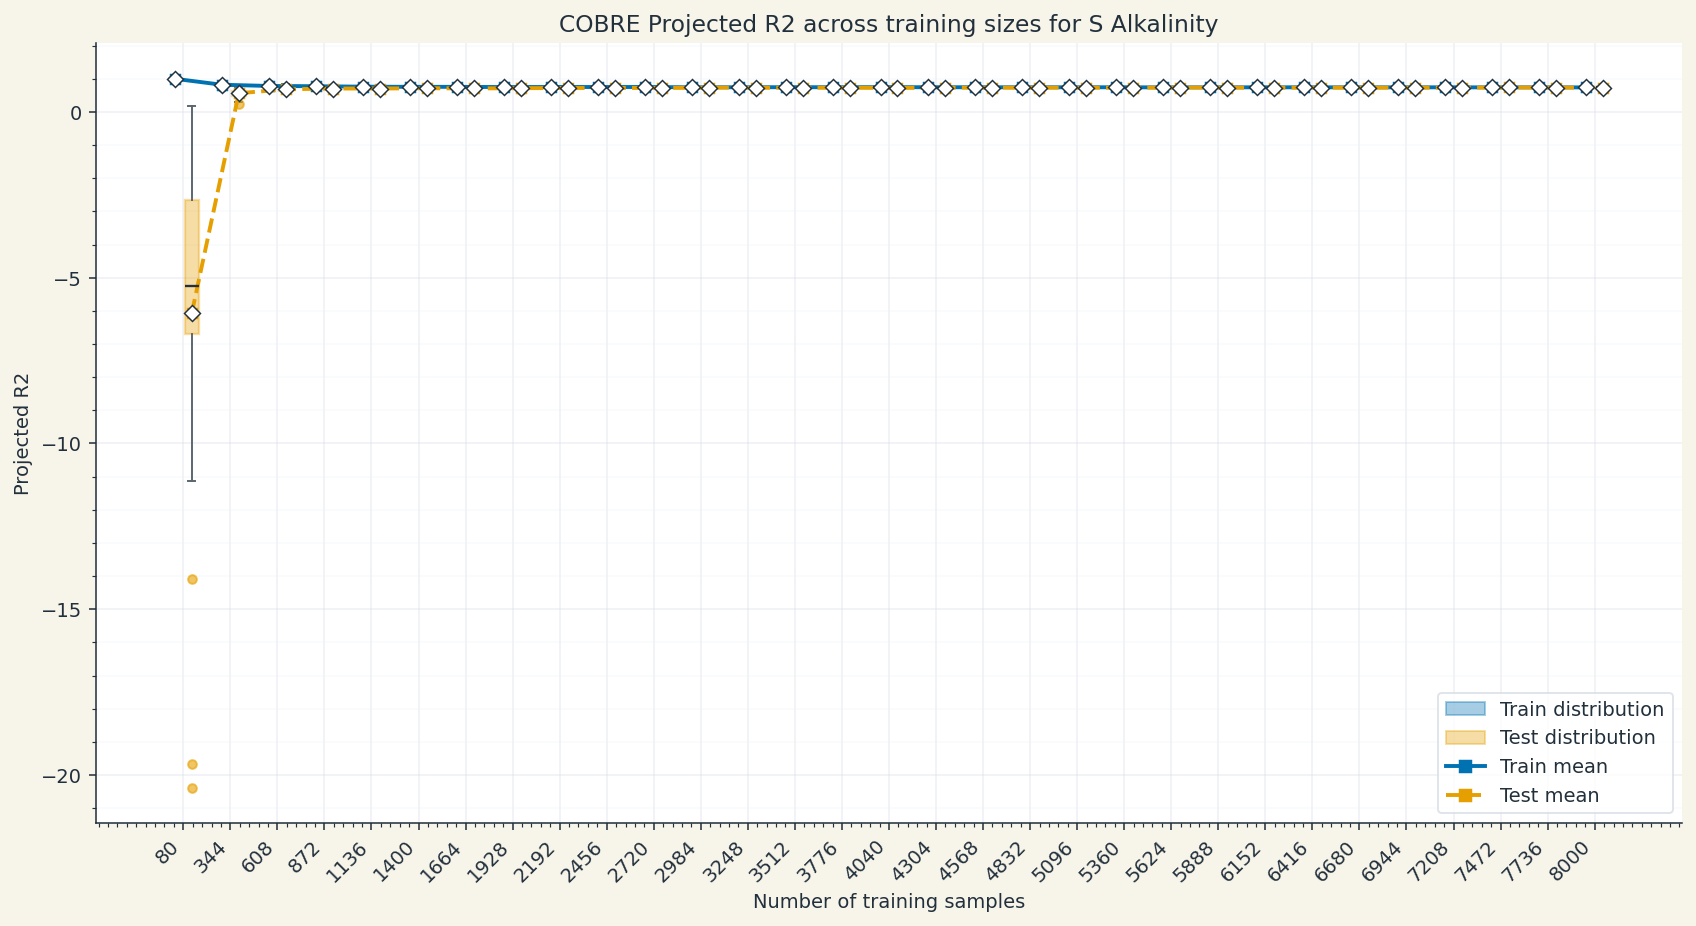

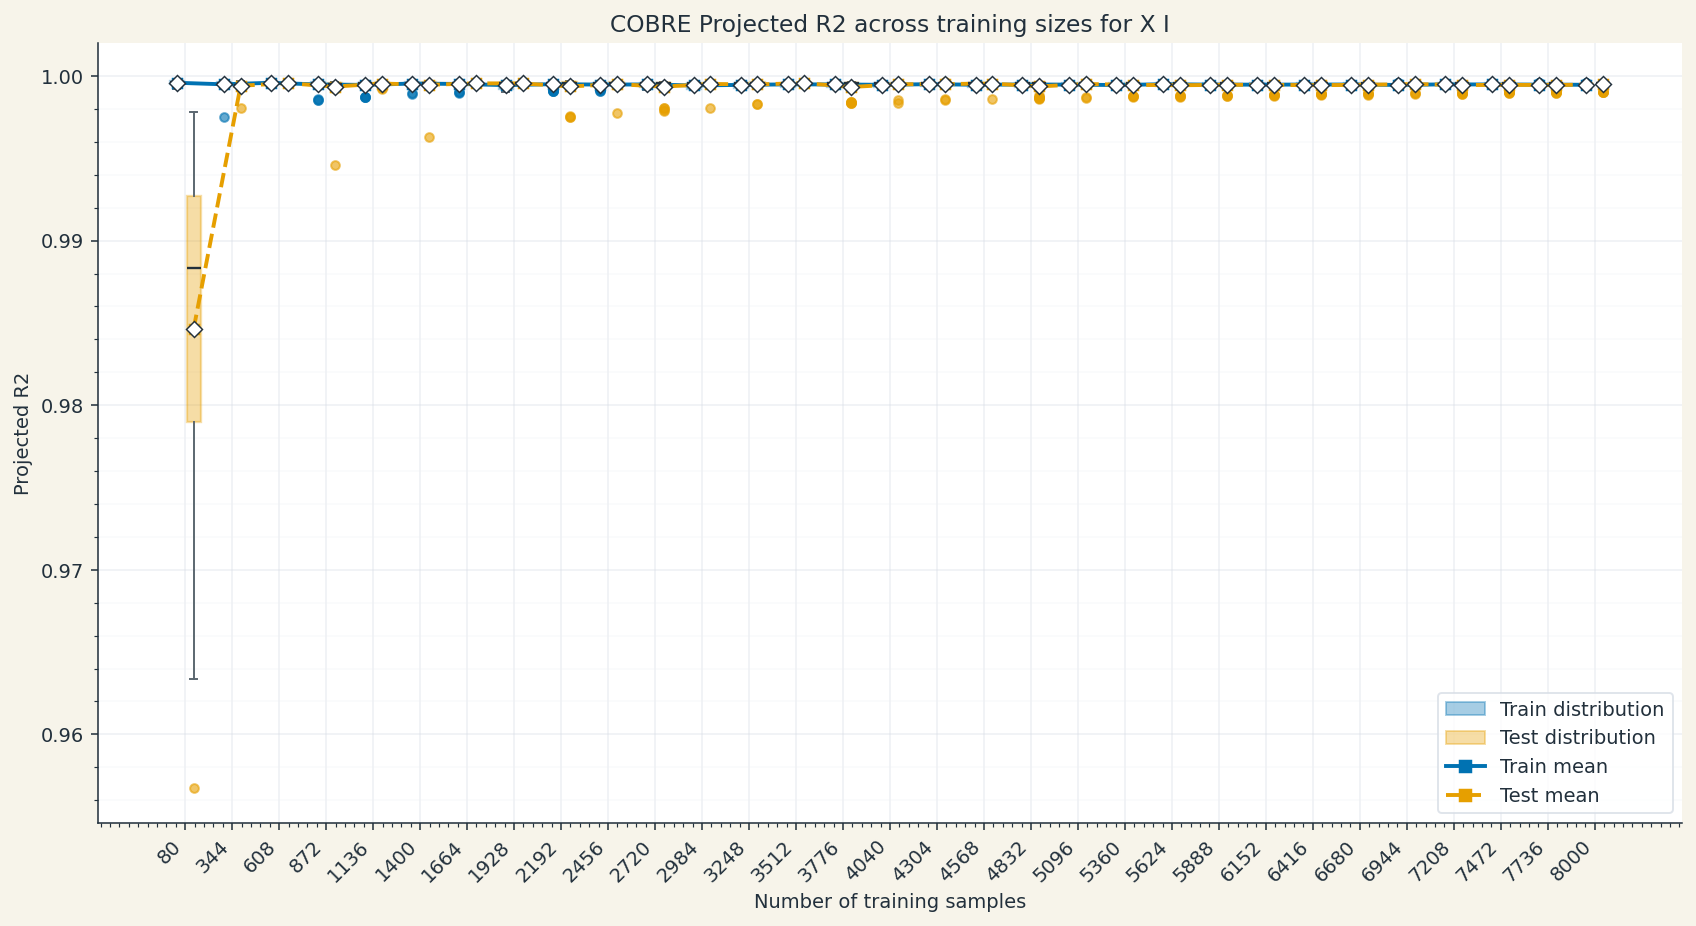

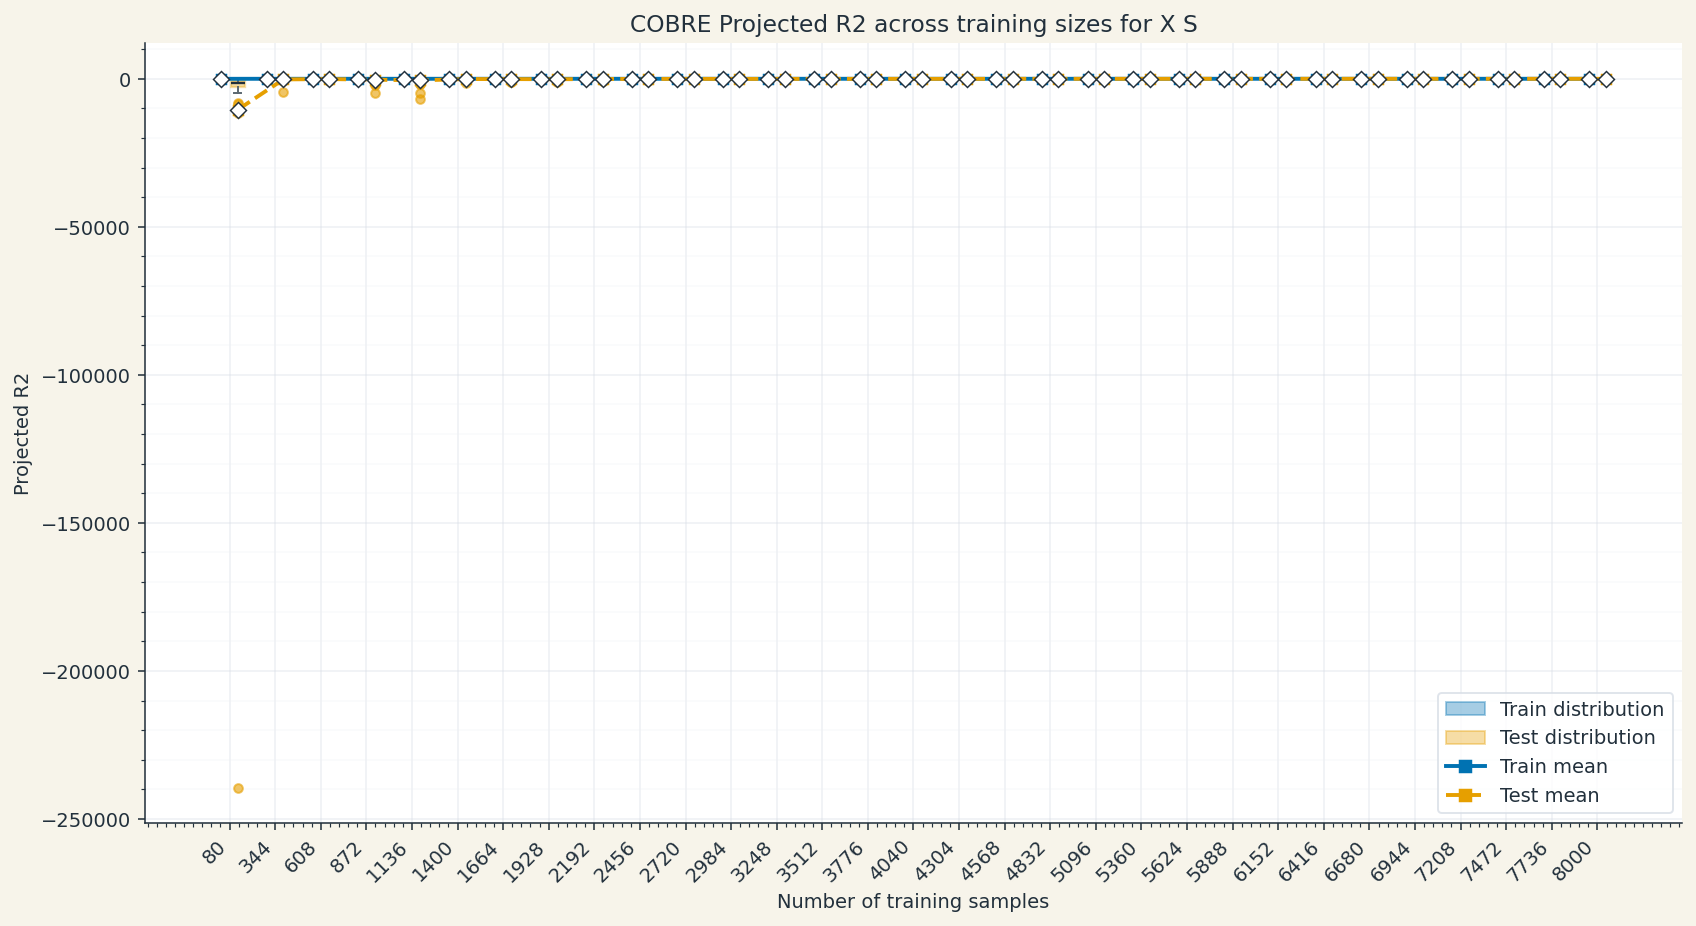

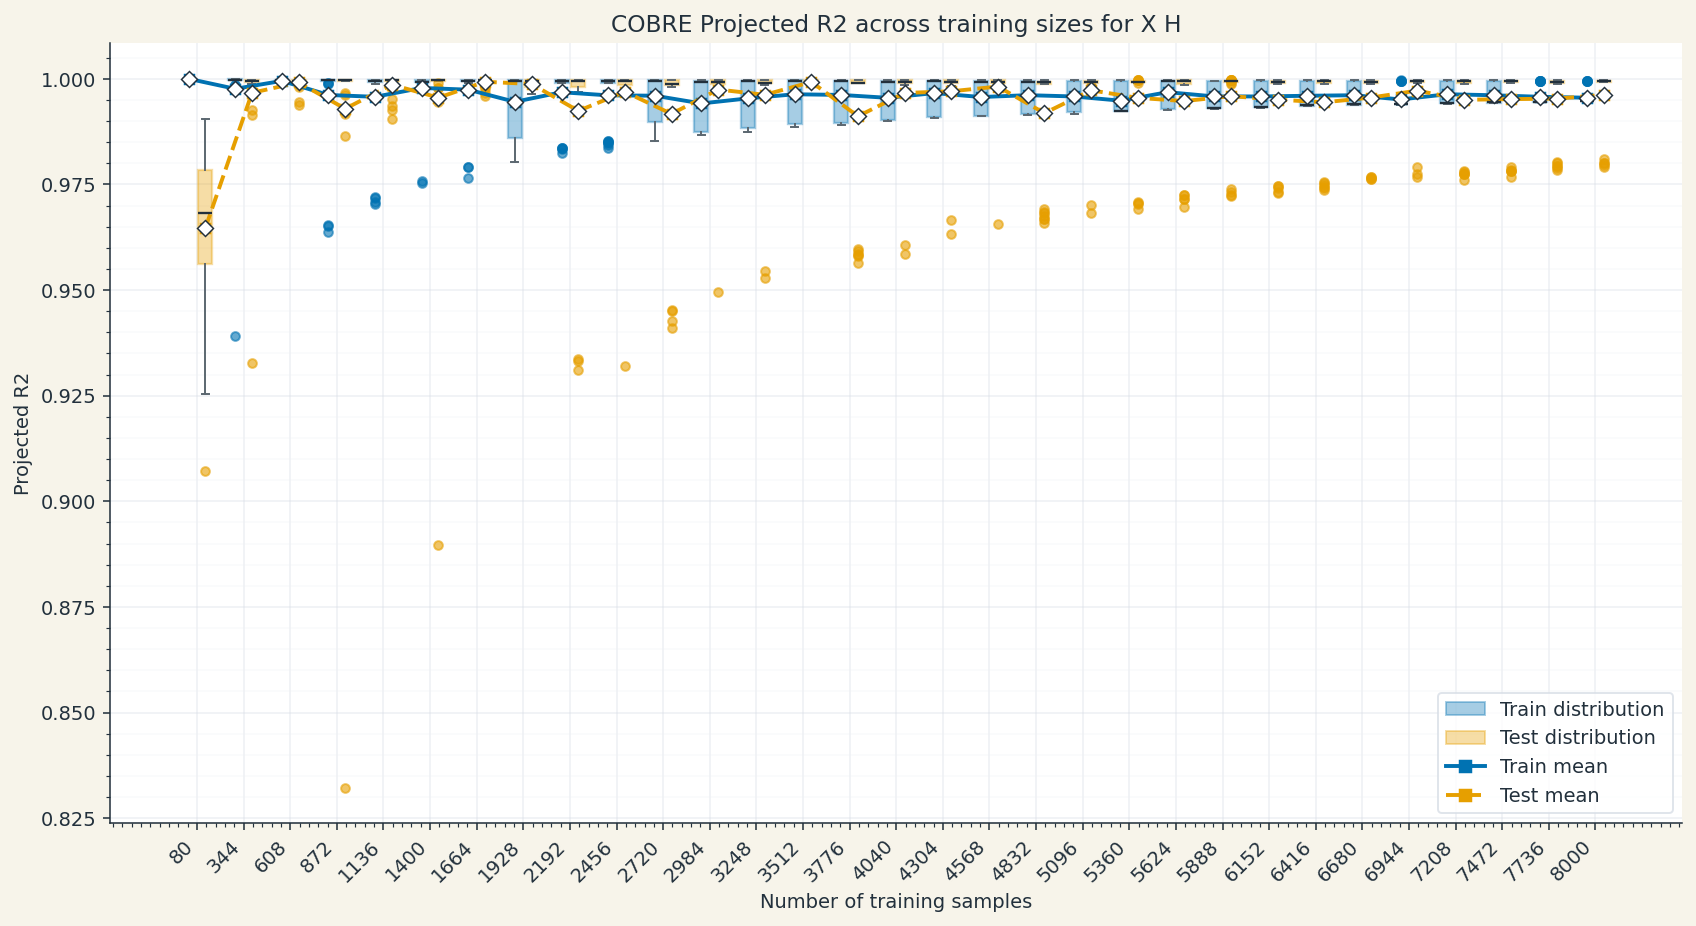

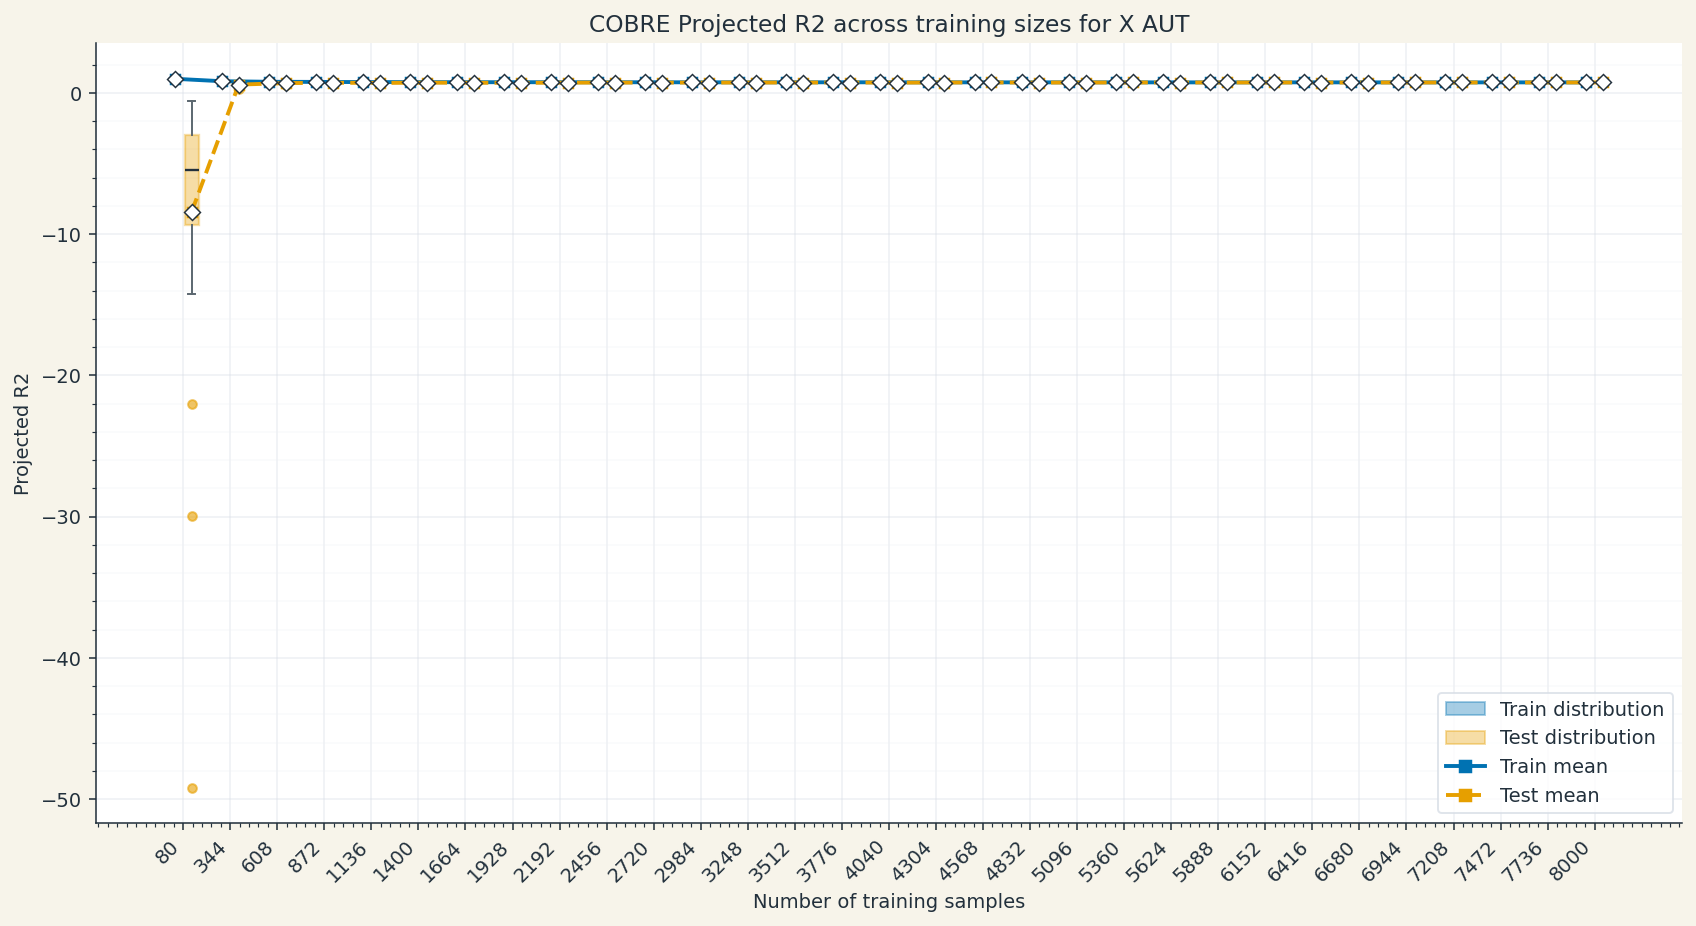

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_cobre_params, run_cobre_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))

cobre_analysis_params = load_cobre_params()
cobre_previous_result = globals().get("cobre_result")
cobre_analysis_hyperparameters = (
    dict(cobre_previous_result["best_hyperparameters"])
    if cobre_previous_result is not None
    else dict(cobre_analysis_params["training_defaults"])
)

cobre_analysis_result = run_model_dataset_size_analysis(
    "cobre",
    cobre_dataset,
    cobre_A_matrix,
    run_cobre_pipeline,
    model_params=cobre_analysis_params,
    model_hyperparameters=cobre_analysis_hyperparameters,
    persist_artifacts=False,
    extra_runner_kwargs={"composition_matrix": composition_matrix},
    **analysis_overrides,
)

print("COBRE analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(cobre_analysis_result['prediction_tables'])}")
display(pd.DataFrame([cobre_analysis_result["analysis_config"]]))
display(cobre_analysis_result["run_metadata"].head())

for target_name in cobre_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        cobre_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="COBRE",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_xgboost_regressor_params, run_xgboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

xgboost_analysis_params = load_xgboost_regressor_params()
xgboost_previous_result = classical_results.get("xgboost_regressor")
xgboost_analysis_hyperparameters = (
    dict(xgboost_previous_result["best_hyperparameters"])
    if xgboost_previous_result is not None
    else dict(xgboost_analysis_params["training_defaults"])
 )

xgboost_analysis_result = run_model_dataset_size_analysis(
    "xgboost_regressor",
    measured_dataset,
    A_matrix,
    run_xgboost_regressor_pipeline,
    model_params=xgboost_analysis_params,
    model_hyperparameters=xgboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("XGBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(xgboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([xgboost_analysis_result["analysis_config"]]))
display(xgboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        xgboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="XGBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_lightgbm_regressor_params, run_lightgbm_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

lightgbm_analysis_params = load_lightgbm_regressor_params()
lightgbm_previous_result = classical_results.get("lightgbm_regressor")
lightgbm_analysis_hyperparameters = (
    dict(lightgbm_previous_result["best_hyperparameters"])
    if lightgbm_previous_result is not None
    else dict(lightgbm_analysis_params["training_defaults"])
 )

lightgbm_analysis_result = run_model_dataset_size_analysis(
    "lightgbm_regressor",
    measured_dataset,
    A_matrix,
    run_lightgbm_regressor_pipeline,
    model_params=lightgbm_analysis_params,
    model_hyperparameters=lightgbm_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("LightGBM analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(lightgbm_analysis_result['prediction_tables'])}")
display(pd.DataFrame([lightgbm_analysis_result["analysis_config"]]))
display(lightgbm_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        lightgbm_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="LightGBM Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_catboost_regressor_params, run_catboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

catboost_analysis_params = load_catboost_regressor_params()
catboost_previous_result = classical_results.get("catboost_regressor")
catboost_analysis_hyperparameters = (
    dict(catboost_previous_result["best_hyperparameters"])
    if catboost_previous_result is not None
    else dict(catboost_analysis_params["training_defaults"])
 )

catboost_analysis_result = run_model_dataset_size_analysis(
    "catboost_regressor",
    measured_dataset,
    A_matrix,
    run_catboost_regressor_pipeline,
    model_params=catboost_analysis_params,
    model_hyperparameters=catboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("CatBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(catboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([catboost_analysis_result["analysis_config"]]))
display(catboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        catboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="CatBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_adaboost_regressor_params, run_adaboost_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

adaboost_analysis_params = load_adaboost_regressor_params()
adaboost_previous_result = classical_results.get("adaboost_regressor")
adaboost_analysis_hyperparameters = (
    dict(adaboost_previous_result["best_hyperparameters"])
    if adaboost_previous_result is not None
    else dict(adaboost_analysis_params["training_defaults"])
 )

adaboost_analysis_result = run_model_dataset_size_analysis(
    "adaboost_regressor",
    measured_dataset,
    A_matrix,
    run_adaboost_regressor_pipeline,
    model_params=adaboost_analysis_params,
    model_hyperparameters=adaboost_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("AdaBoost analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(adaboost_analysis_result['prediction_tables'])}")
display(pd.DataFrame([adaboost_analysis_result["analysis_config"]]))
display(adaboost_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        adaboost_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="AdaBoost Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_random_forest_regressor_params, run_random_forest_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

random_forest_analysis_params = load_random_forest_regressor_params()
random_forest_previous_result = classical_results.get("random_forest_regressor")
random_forest_analysis_hyperparameters = (
    dict(random_forest_previous_result["best_hyperparameters"])
    if random_forest_previous_result is not None
    else dict(random_forest_analysis_params["training_defaults"])
 )

random_forest_analysis_result = run_model_dataset_size_analysis(
    "random_forest_regressor",
    measured_dataset,
    A_matrix,
    run_random_forest_regressor_pipeline,
    model_params=random_forest_analysis_params,
    model_hyperparameters=random_forest_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("Random forest analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(random_forest_analysis_result['prediction_tables'])}")
display(pd.DataFrame([random_forest_analysis_result["analysis_config"]]))
display(random_forest_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        random_forest_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="Random Forest Regressor",
    )
    display(figure)
    plt.close(figure)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from src.models.ml import load_svr_regressor_params, run_svr_regressor_pipeline
from src.utils.analysis import run_model_dataset_size_analysis
from src.utils.plot import plot_train_test_metric_boxplots

analysis_metric = str(globals().get("analysis_metric", "projected_R2"))
analysis_overrides = dict(globals().get("analysis_overrides", {}))
classical_results = dict(globals().get("classical_regressor_results", {}))

svr_analysis_params = load_svr_regressor_params()
svr_previous_result = classical_results.get("svr_regressor")
svr_analysis_hyperparameters = (
    dict(svr_previous_result["best_hyperparameters"])
    if svr_previous_result is not None
    else dict(svr_analysis_params["training_defaults"])
 )

svr_analysis_result = run_model_dataset_size_analysis(
    "svr_regressor",
    measured_dataset,
    A_matrix,
    run_svr_regressor_pipeline,
    model_params=svr_analysis_params,
    model_hyperparameters=svr_analysis_hyperparameters,
    persist_artifacts=False,
    **analysis_overrides,
 )

print("SVR analysis complete.")
print(f"Metric: {analysis_metric}")
print(f"Prediction tables returned: {len(svr_analysis_result['prediction_tables'])}")
display(pd.DataFrame([svr_analysis_result["analysis_config"]]))
display(svr_analysis_result["run_metadata"].head())

for target_name in measured_dataset.targets.columns:
    figure, _ = plot_train_test_metric_boxplots(
        svr_analysis_result["per_target_metrics"],
        metric_name=analysis_metric,
        target_name=target_name,
        model_name="SVR Regressor",
    )
    display(figure)
    plt.close(figure)